Saving insurance.csv to insurance (3).csv
File used: insurance (3).csv
MAE: 4145.450555627587
MSE: 33780509.57479164
RMSE: 5812.100272258871
R2: 0.7696118054369011


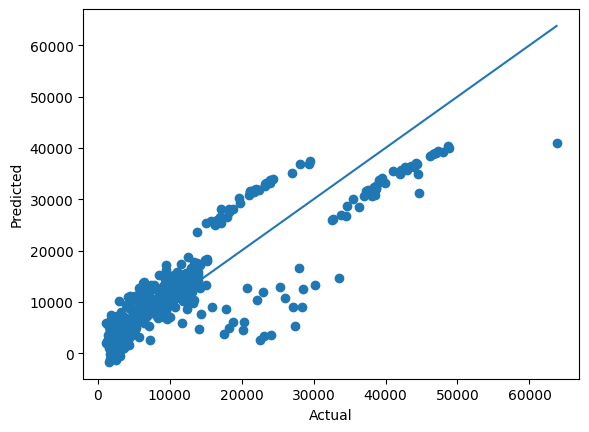

In [8]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df = pd.get_dummies(df, drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("File used:", list(uploaded.keys())[0])

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Saving insurance.csv to insurance (4).csv
File used: insurance (4).csv
Best Alpha: {'alpha': 1}
MAE: 4158.791710342997
MSE: 33818241.88764884
RMSE: 5815.34537991071
R2: 0.7693544653450765


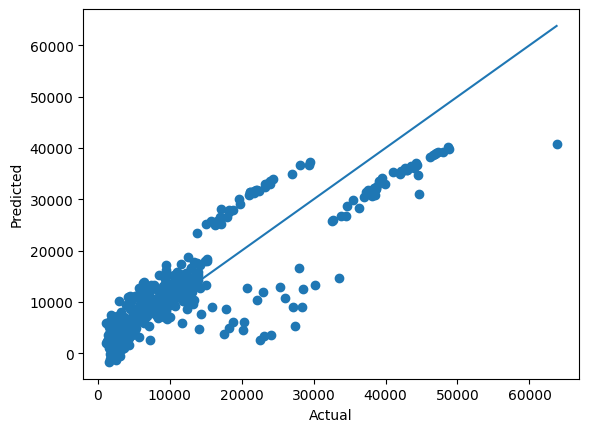

In [9]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn import metrics

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df = pd.get_dummies(df, drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

params = {'alpha': [0.1, 1, 10]}

ridge = Ridge()
grid = GridSearchCV(ridge, params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("File used:", list(uploaded.keys())[0])
print("Best Alpha:", grid.best_params_)

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Saving insurance.csv to insurance (5).csv
File used: insurance (5).csv
Accuracy: 0.9029850746268657


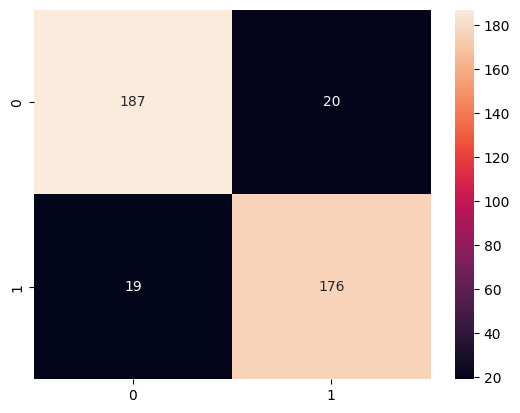

In [10]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df = pd.get_dummies(df, drop_first=True)

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("File used:", list(uploaded.keys())[0])

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

Saving insurance.csv to insurance (6).csv
File used: insurance (6).csv
Best C: {'C': 1}
Accuracy: 0.9029850746268657


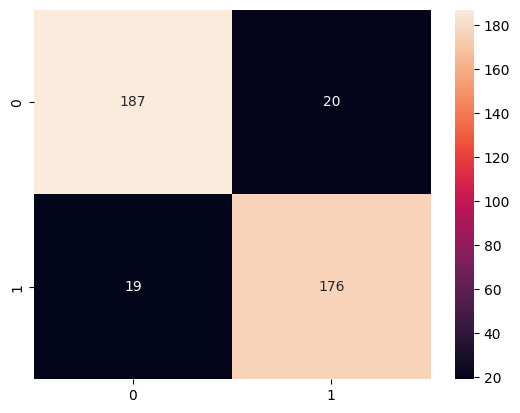

In [11]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df = pd.get_dummies(df, drop_first=True)

df['target'] = (df['charges'] > df['charges'].median()).astype(int)

X = df.drop(['charges', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

params = {'C': [0.01, 0.1, 1, 10, 100]}

model = LogisticRegression(max_iter=10000)
grid = GridSearchCV(model, params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("File used:", list(uploaded.keys())[0])
print("Best C:", grid.best_params_)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()